---
# Inicio
---

Esta sección comprende el primer contacto técnico con los datos de **AndesLink**. El objetivo es validar la integridad de la información y extraer los patrones preliminares que explican el fenómeno de abandono (Churn).

Como primera instancia haremos:

- Analisis del dataset = cuantos registros y features

- Hay valores nulos?

- Tipos de features

- Variable objetivo

- porcentaje de churn vs no churn = balanceo del dataset

- relacion entre variables

- multicolinealidad

- Que cliente tiene mas chance de irse, el nuevo o el viejo? el de facturacion mensual/anual/bianual?

- De los que se van, que tipo de contrato?

- morosidad?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
### Exploración Inicial y Calidad del Dataset

In [2]:
pd.set_option('display.max_columns', None)
df = pd.read_csv('data/raw/churn_sintetico.csv')
df.head()

,tenure_months,monthly_charge,total_charges,support_tickets,late_payments,avg_monthly_usage_gb,contract_type,payment_method,internet_service,has_streaming,has_security_pack,num_products,region,customer_age,is_promo,churn
0,7,58.23,326.50,2,1,81.83,mensual,transferencia,cable,0,1,3,centro,53,1,1
1,56,56.75,3154.21,0,2,96.52,anual,debito,fibra,0,0,4,centro,53,0,0
2,48,78.84,3864.31,3,2,93.60,bianual,efectivo,movil,1,1,4,centro,73,1,1
3,32,79.74,2511.40,0,0,28.95,bianual,debito,movil,0,1,4,norte,25,0,1
4,32,55.37,1735.51,3,0,126.90,anual,efectivo,fibra,1,0,2,oeste,61,1,0


In [3]:
print("--- TAMAÑO DEL DATASET ---")
print(f"Total de registros (filas): {df.shape[0]}")
print(f"Total de features (columnas): {df.shape[1]}\n")

print("--- INFORMACIÓN TÉCNICA Y TIPOS DE DATOS ---")
df.info()

print("\n--- VALORES NULOS POR COLUMNA ---")
nulos = df.isnull().sum()
if nulos.sum() == 0:
    print("Confirmado: El dataset no contiene valores nulos.")
else:
    print(nulos[nulos > 0])

--- TAMAÑO DEL DATASET ---
Total de registros (filas): 5000
Total de features (columnas): 16

--- INFORMACIÓN TÉCNICA Y TIPOS DE DATOS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tenure_months         5000 non-null   int64  
 1   monthly_charge        5000 non-null   float64
 2   total_charges         5000 non-null   float64
 3   support_tickets       5000 non-null   int64  
 4   late_payments         5000 non-null   int64  
 5   avg_monthly_usage_gb  5000 non-null   float64
 6   contract_type         5000 non-null   object 
 7   payment_method        5000 non-null   object 
 8   internet_service      5000 non-null   object 
 9   has_streaming         5000 non-null   int64  
 10  has_security_pack     5000 non-null   int64  
 11  num_products          5000 non-null   int64  
 12  region                5000 non-null

### Dimensiones y Calidad de Datos
El dataset provisto por la cátedra consta de **5,000 registros y 16 variables**. Tras realizar la inspección técnica, se confirma que el conjunto de datos no presenta valores nulos, lo que garantiza una base sólida para el entrenamiento sin necesidad de técnicas de imputación.


---
### Análisis de Outliers y Distribución de Contratos

--- ANÁLISIS DE OUTLIERS (VALORES ATÍPICOS) ---


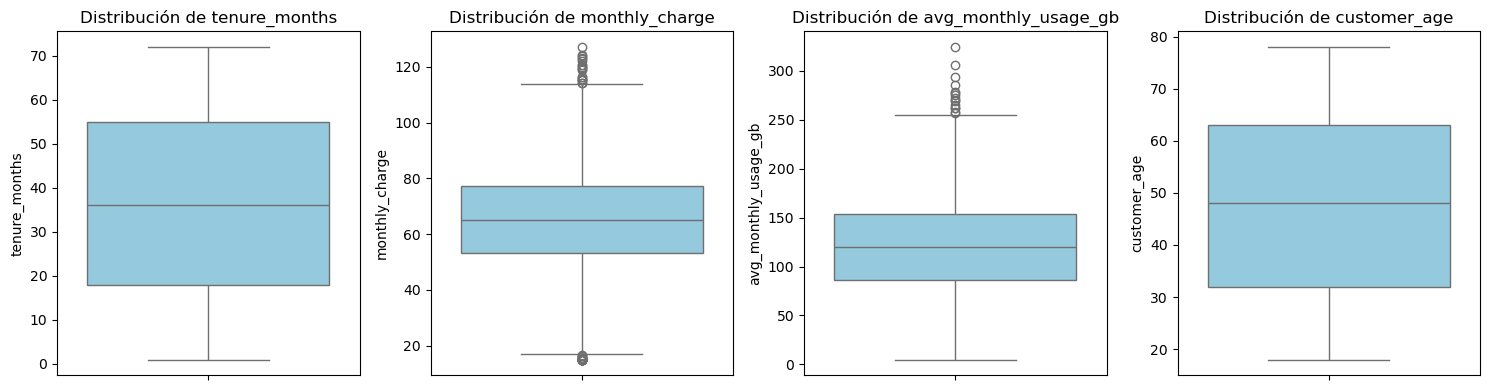


--- DISTRIBUCIÓN DE TIPOS DE CONTRATO ---
contract_type
mensual    2750
anual      1411
bianual     839
Name: count, dtype: int64


In [4]:
print("--- ANÁLISIS DE OUTLIERS (VALORES ATÍPICOS) ---")
# Seleccionamos variables numéricas clave para buscar outliers
cols_outliers = ['tenure_months', 'monthly_charge', 'avg_monthly_usage_gb', 'customer_age']

plt.figure(figsize=(15, 4))
for i, col in enumerate(cols_outliers):
    plt.subplot(1, 4, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

# Verificamos la frecuencia de los tipos de contrato para validar la hipótesis
print("\n--- DISTRIBUCIÓN DE TIPOS DE CONTRATO ---")
print(df['contract_type'].value_counts())

Tras visualizar las distribuciones de las variables numéricas principales, observamos lo siguiente:

1. **Variables Numéricas:** No se detectan outliers significativos en variables como `monthly_charge` o `avg_monthly_usage_gb`. Los valores se mantienen dentro de rangos esperados para el negocio, indicando que el dataset sintético está bastante limpio y balanceado en sus escalas.

2. **Tipos de Contrato y el concepto de Outlier:** 
   * Es importante aclarar que una baja frecuencia en una categoría (como los contratos **bianuales**) no constituye un "outlier" en el sentido estadístico tradicional. Un outlier es un valor numérico extremo que se aleja del promedio de su propia distribución. 
   * En este caso, el contrato bianual es simplemente una **categoría minoritaria**. Aunque son menos registros, sus valores de antigüedad o cargos no presentan comportamientos anómalos o imposibles que requieran ser tratados como ruido.
   * Sin embargo, esta menor representatividad nos indica que la gran mayoría de la base de clientes prefiere un contrato mensual, lo cual eleva el riesgo global de churn.

---
### Análisis de Multicolinealidad

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

--- MATRIZ DE CORRELACIÓN (MULTICOLINEALIDAD) ---


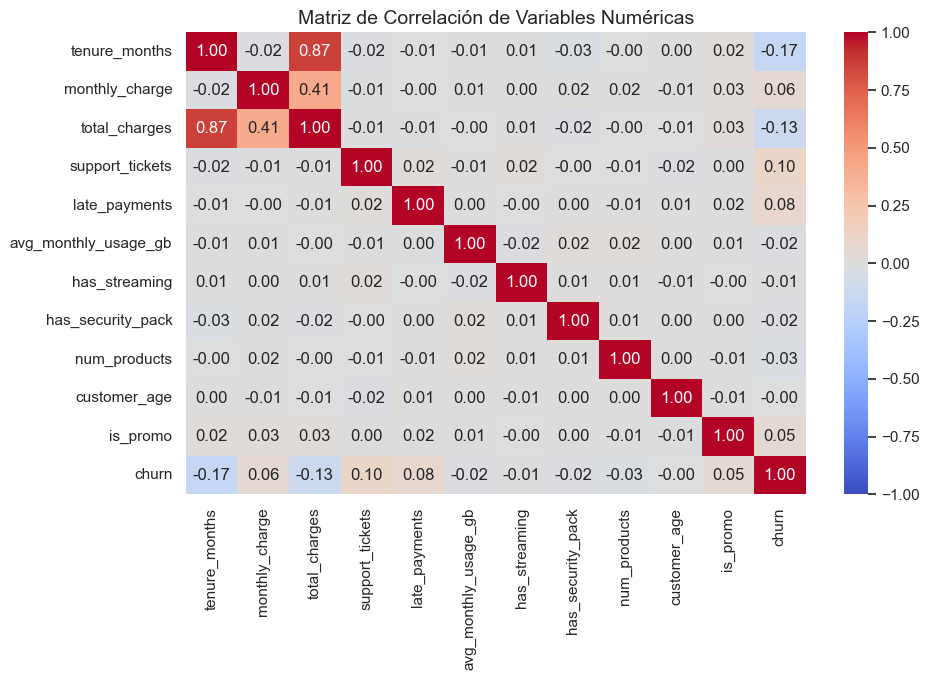

In [6]:
sns.set_theme(style="whitegrid")

print("--- MATRIZ DE CORRELACIÓN (MULTICOLINEALIDAD) ---")
plt.figure(figsize=(10, 6))

# Correlacion de variables numericas
cols_numericas = df.select_dtypes(include=['int64', 'float64']).columns
correlacion = df[cols_numericas].corr()

# Heatmap
sns.heatmap(correlacion, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlación de Variables Numéricas", fontsize=14)
plt.show()


Al analizar la matriz de correlación, detectamos una alta multicolinealidad estructural involucrando a la variable `total_charges`. 

**¿Por qué ocurre esto?**
La variable `total_charges` no representa un comportamiento independiente, sino que es esencialmente el resultado de una operación matemática directa: la antigüedad del cliente (`tenure_months`) multiplicada por su tarifa mensual (`monthly_charge`). Es decir, es información redundante.

**Impacto en el Modelado:**
En Machine Learning, alimentar a un algoritmo con variables que expresan exactamente la misma información (dependencia lineal) genera problemas de multicolinealidad. Esto "confunde" al modelo, dificultando que el algoritmo asigne el peso correcto a cada factor y diluyendo la interpretabilidad de las variables más importantes.

**Decisión Analítica:**
Para evitar la introducción de ruido y garantizar la independencia de nuestras variables predictoras, **se procederá a eliminar la columna `total_charges`** durante la etapa de preprocesamiento y *Feature Engineering* (`src/features/build_features.py`). 

Conservaremos únicamente `tenure_months` (que nos ayuda a medir la fidelidad/lealtad del usuario) y `monthly_charge` (que captura la sensibilidad al precio), ya que ambas son métricas primarias mucho más valiosas y puras para entender los motivos del abandono (Churn).

---
### Análisis de la Variable Objetivo: `churn`

In [7]:
# Columna objetivo: 'churn'
target_col = 'churn'

print("--- DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ---")
conteo = df[target_col].value_counts()
porcentaje = df[target_col].value_counts(normalize=True) * 100

# Armamos un DataFrame pequeño para verlo prolijo
balance_df = pd.DataFrame({
    'Cantidad': conteo,
    'Porcentaje (%)': porcentaje.round(2)
})

print(balance_df)

--- DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ---
       Cantidad  Porcentaje (%)
churn                          
0          3298           65.96
1          1702           34.04



Se ha identificado una distribución desbalanceada en la variable objetivo:
* **Permanencia (0):** 65.96%
* **Abandono (1):** 34.04%

Este desbalanceo nos indica que el modelo no puede ser evaluado únicamente por su *Accuracy*, sino que deberemos priorizar métricas como el **Recall** o el **F1-Score** para asegurar que estamos detectando correctamente a los clientes con alta probabilidad de fuga.

---
### Análisis de Negocio


--- ANÁLISIS DE NEGOCIO: TIPO DE CONTRATO VS CHURN ---


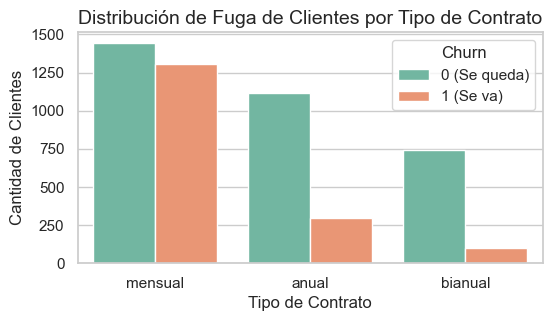

In [8]:
print("\n--- ANÁLISIS DE NEGOCIO: TIPO DE CONTRATO VS CHURN ---")
plt.figure(figsize=(6, 3))
sns.countplot(data=df, x='contract_type', hue='churn', palette='Set2')
plt.title("Distribución de Fuga de Clientes por Tipo de Contrato", fontsize=14)
plt.ylabel("Cantidad de Clientes")
plt.xlabel("Tipo de Contrato")
plt.legend(title="Churn", labels=['0 (Se queda)', '1 (Se va)'])
plt.show()

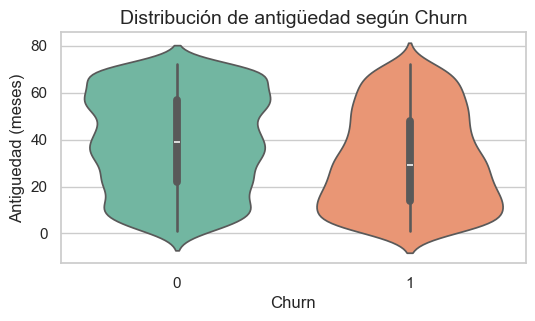

In [9]:
plt.figure(figsize=(6, 3))
sns.violinplot(data=df, x='churn', y='tenure_months', hue='churn', palette='Set2', legend=False)
plt.title("Distribución de antigüedad según Churn", fontsize=14)
plt.ylabel("Antiguedad (meses)")
plt.xlabel("Churn")
plt.show()

In [10]:
print("--- TASA DE CHURN POR TIPO DE CONTRATO ---")
churn_contrato = df.groupby('contract_type')['churn'].mean() * 100
print(churn_contrato.round(1).astype(str) + " %")

print("\n--- TASA DE CHURN POR SERVICIO DE INTERNET ---")
churn_internet = df.groupby('internet_service')['churn'].mean() * 100
print(churn_internet.round(1).astype(str) + " %")

print("\n--- CORRELACIONES CLAVE CON LA VARIABLE CHURN ---")
# Aislamos las variables de lealtad y fricción para ver su correlación directa con la fuga
cols_analisis = ['tenure_months', 'support_tickets', 'late_payments', 'churn']
correlacion_churn = df[cols_analisis].corr()['churn'].drop('churn')
print(correlacion_churn.round(3))

--- TASA DE CHURN POR TIPO DE CONTRATO ---
contract_type
anual      21.1 %
bianual    11.6 %
mensual    47.5 %
Name: churn, dtype: object

--- TASA DE CHURN POR SERVICIO DE INTERNET ---
internet_service
cable      34.8 %
fibra      26.8 %
movil      50.9 %
ninguno    28.8 %
Name: churn, dtype: object

--- CORRELACIONES CLAVE CON LA VARIABLE CHURN ---
tenure_months     -0.170
support_tickets    0.102
late_payments      0.081
Name: churn, dtype: float64


---
---

### Hallazgos Clave del Análisis Bivariado y Correlaciones

Tras analizar el comportamiento de la variable objetivo frente a las características del servicio y del cliente, identificamos cuatro vectores principales de riesgo (Churn):

1. **El Compromiso a Corto Plazo (`contract_type`):** Existe una vulnerabilidad extrema en los contratos de renovación mensual, los cuales presentan una tasa de abandono del **47.5%**. Este riesgo disminuye drásticamente a un **11.6%** en clientes con contratos bianuales. La ausencia de barreras de salida en el formato mensual facilita la fuga rápida.

2. **La Estabilidad del Servicio (`internet_service`):** El tipo de conexión es un factor determinante en la retención. Los clientes con servicio móvil abandonan a un ritmo alarmante (**50.9%**), prácticamente el doble que los usuarios de fibra óptica (**26.8%**). Esto sugiere fuertemente problemas de calidad, percepción de valor o estabilidad en el servicio móvil frente a la robustez de la fibra.

3. **La Lealtad y Maduración (`tenure_months`):** Confirmamos la hipótesis de retención histórica: la antigüedad presenta una correlación negativa (**-0.17**) con el Churn. A mayor cantidad de meses en el servicio, el riesgo de fuga se reduce. Esto indica que los esfuerzos de retención (campañas, descuentos, acompañamiento) deben ser sumamente agresivos durante los primeros meses de *onboarding* del usuario.

4. **Fricción Operativa y Estrés Financiero (`support_tickets` y `late_payments`):**
   Las variables que representan "fricción" muestran correlaciones positivas con la fuga. Un cliente que acumula *tickets* de soporte técnico (insatisfacción operativa) o que presenta morosidad en sus pagos (estrés financiero/desconexión del servicio) se convierte inmediatamente en un perfil de altísimo riesgo de cancelación inminente..

### Síntesis de Hallazgos de Negocio
Los cruces de variables realizados permiten establecer los siguientes perfiles de riesgo:
* **Fragilidad Contractual:** El contrato mensual es el mayor predictor de fuga, con un **47.5% de churn**.
* **Problemas de Servicio:** Los usuarios de servicio móvil tienen una tasa de abandono significativamente mayor (**50.9%**) que los de fibra óptica.
* **Fricción Operativa:** Se detecta una correlación directa entre la insatisfacción (tickets de soporte) y la morosidad (pagos atrasados) con el riesgo de abandono, aunque no es de riesgo inminente.

### Recomendación Estratégica
Dada la baja correlación entre la fricción operativa y el abandono voluntario, estos indicadores se interpretan como señales de atención para la mejora del servicio y no necesariamente como disparadores de campañas de retención. 

Desde una perspectiva de eficiencia operativa, se sugiere priorizar la estabilidad del producto (especialmente en el segmento móvil) y la optimización de los procesos de cobranza antes de invertir presupuesto de marketing en retener perfiles que presentan insatisfacción técnica o estrés financiero.

---
---
